# COCA Dataset Preprocessing Pipeline
## Project 1: Heart Segmentation Model

This notebook implements a comprehensive preprocessing pipeline for cardiac CT segmentation including:
- HU windowing for cardiac CT
- Data augmentation
- Stratified train/val/test split
- Efficient data loading optimized for segmentation

## 1. Setup and Configuration

In [1]:
# Standard library imports
import os
import glob
import json
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Medical imaging libraries
import SimpleITK as sitk

# Deep learning libraries
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# MONAI for medical image processing
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, Spacing, Orientation,
    RandRotate90,RandAffine, RandGaussianNoise,
    RandGaussianSmooth, RandScaleIntensity, RandShiftIntensity,
    ToTensor, EnsureType,Rand3DElastic
)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")

c:\CT_Datasets\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!


In [2]:
# Configuration
class Config:
    # Paths
    BASE_DIR = Path(r"C:\CT_Datasets")
    DATA_DIR = BASE_DIR / "totalsegmentator_output"  
    ORIGINAL_DATA_DIR = BASE_DIR / "data_resampled"  # Original calcium segmentations
    CANONICAL_DIR = BASE_DIR / "data_canonical"
    SCAN_INDEX = CANONICAL_DIR / "tables" / "scan_index.csv"
    OUTPUT_DIR = BASE_DIR / "preprocessed_data"
    
    # HU windowing parameters for cardiac CT
    # Standard cardiac window: captures heart tissue, vessels, and calcification
    PRIMARY_WINDOW_CENTER = 100  # HU
    PRIMARY_WINDOW_WIDTH = 600   # HU
    HU_MIN = PRIMARY_WINDOW_CENTER - (PRIMARY_WINDOW_WIDTH // 2)  # -200
    HU_MAX = PRIMARY_WINDOW_CENTER + (PRIMARY_WINDOW_WIDTH // 2)  # 400
    
    # Optional multi-window input (soft tissue + broader cardiac window)
    USE_MULTI_WINDOW = True
    WINDOW_PAIRS = [
        {"center": 40,  "width": 400},
        {"center": 100, "width": 600},
    ]
    
    # Data split ratios
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # Data loader parameters
    BATCH_SIZE = 4
    NUM_WORKERS = 0  
    PIN_MEMORY = True
    
    # Image parameters
    TARGET_SPACING = (0.7, 0.7, 3.0)  # mm - matches pre-resampled COCA pipeline spacing
    
    # Create output directory
    OUTPUT_DIR.mkdir(exist_ok=True)
    
config = Config()
print(f"Data directory: {config.DATA_DIR}")
print("Using TotalSegmentator heart segmentations (not calcium)")
if config.USE_MULTI_WINDOW:
    print(f"Multi-window input: {config.WINDOW_PAIRS}")
else:
    print(f"Cardiac HU window: [{config.HU_MIN}, {config.HU_MAX}]")

Data directory: C:\CT_Datasets\totalsegmentator_output
Using TotalSegmentator heart segmentations (not calcium)
Multi-window input: [{'center': 40, 'width': 400}, {'center': 100, 'width': 600}]


## 2. Data Exploration and Statistics

In [3]:
# Load scan index
scan_df = pd.read_csv(config.SCAN_INDEX)
print(f"Total scans in dataset: {len(scan_df)}")
print(f"\nDataset overview:")
print(scan_df.head())

# Check available scans with heart segmentations from TotalSegmentator
print(f"\nLoading scans from: {config.DATA_DIR}")
print("Note: Using TotalSegmentator-generated heart segmentations")

if not config.DATA_DIR.exists():
    print(f"\n{'='*80}")
    print(" TOTALSEGMENTATOR OUTPUT DIRECTORY NOT FOUND!")
    print("="*80)
    print(f"\nExpected directory: {config.DATA_DIR}")
    print("\nYou need to run TotalSegmentator first:")
    print("\n  1. Run: python run_totalsegmentator.py")
    print("  2. Wait for TotalSegmentator to process 50 scans (~2-3 hours)")
    print("  3. Then re-run this preprocessing notebook")
    print(f"\n{'='*80}")
    raise FileNotFoundError(f"Directory not found: {config.DATA_DIR}")

resampled_scans = sorted([d.name for d in config.DATA_DIR.iterdir() if d.is_dir()])
print(f"Total scans with heart segmentations: {len(resampled_scans)}")

# Verify data integrity - all scans should have both image and heart segmentation
valid_scans = []
for scan_id in tqdm(resampled_scans, desc="Checking data integrity"):
    img_path = config.DATA_DIR / scan_id / f"{scan_id}_img.nii.gz"
    seg_path = config.DATA_DIR / scan_id / f"{scan_id}_seg.nii.gz"
    
    if img_path.exists() and seg_path.exists():
        valid_scans.append(scan_id)

print(f"\nValid scans (with both image and heart segmentation): {len(valid_scans)} / {len(resampled_scans)}")

if len(valid_scans) == 0:
    print("\n" + "="*80)
    print(" NO VALID SCANS FOUND!")
    print("="*80)
    print("\nMake sure you ran: python run_totalsegmentator.py")
    print("Check that totalsegmentator_output/ contains subdirectories with data.")
    print("="*80)
    raise ValueError("No valid scans found. Run TotalSegmentator first!")

all_valid_scans = valid_scans
print(f"Proceeding with {len(all_valid_scans)} scans for training")

Total scans in dataset: 787

Dataset overview:
   patient_id       scan_id  voxels  num_slices  \
0           0  cad4693140b7      22           1   
1           1  46b5424d7aaf     952           8   
2          10  886a20e2098f     390          14   
3         100  9a82f9b73b29     885          16   
4         101  282b7f762f6a      21           1   

                                         folder_path  
0  C:\CT_Datasets\data_canonical\images\cad4693140b7  
1  C:\CT_Datasets\data_canonical\images\46b5424d7aaf  
2  C:\CT_Datasets\data_canonical\images\886a20e2098f  
3  C:\CT_Datasets\data_canonical\images\9a82f9b73b29  
4  C:\CT_Datasets\data_canonical\images\282b7f762f6a  

Loading scans from: C:\CT_Datasets\totalsegmentator_output
Note: Using TotalSegmentator-generated heart segmentations
Total scans with heart segmentations: 50


Checking data integrity: 100%|██████████| 50/50 [00:00<00:00, 3125.13it/s]


Valid scans (with both image and heart segmentation): 50 / 50
Proceeding with 50 scans for training


In [4]:
# Analyze dataset statistics
def analyze_scan(scan_id):
    """Analyze a single scan for statistics."""
    img_path = config.DATA_DIR / scan_id / f"{scan_id}_img.nii.gz"
    seg_path = config.DATA_DIR / scan_id / f"{scan_id}_seg.nii.gz"
    
    try:
        # Load image
        img_sitk = sitk.ReadImage(str(img_path))
        img_array = sitk.GetArrayFromImage(img_sitk)
        
        # Load segmentation
        seg_sitk = sitk.ReadImage(str(seg_path))
        seg_array = sitk.GetArrayFromImage(seg_sitk)
        
        # Get statistics
        stats = {
            'scan_id': scan_id,
            'shape': img_array.shape,
            'spacing': img_sitk.GetSpacing(),
            'hu_min': float(img_array.min()),
            'hu_max': float(img_array.max()),
            'hu_mean': float(img_array.mean()),
            'hu_std': float(img_array.std()),
            'has_segmentation': seg_array.max() > 0,
            'seg_volume_voxels': int((seg_array > 0).sum()),
            'seg_ratio': float((seg_array > 0).sum() / seg_array.size)
        }
        return stats
    except Exception as e:
        print(f"Error analyzing {scan_id}: {e}")
        return None

# Analyze a sample of scans
sample_size = min(50, len(all_valid_scans))
sample_scans = np.random.choice(all_valid_scans, sample_size, replace=False)

scan_stats = []
for scan_id in tqdm(sample_scans, desc="Analyzing scans"):
    stats = analyze_scan(scan_id)
    if stats:
        scan_stats.append(stats)
        
stats_df = pd.DataFrame(scan_stats)
print(f"\nDataset Statistics (n={len(stats_df)}):")
print(stats_df.describe())

Analyzing scans: 100%|██████████| 50/50 [00:05<00:00,  8.90it/s]


Dataset Statistics (n=50):
            hu_min       hu_max     hu_mean       hu_std  seg_volume_voxels  \
count    50.000000    50.000000   50.000000    50.000000          50.000000   
mean  -1102.900000  1902.400000 -255.626949   411.757977      484334.020000   
std     396.130995   861.664644  146.833914   162.217424      108543.945673   
min   -3024.000000   786.000000 -986.440338   271.902029      312034.000000   
25%   -1024.000000  1248.500000 -289.971480   359.040187      416416.750000   
50%   -1024.000000  1401.000000 -226.420203   380.463437      475487.000000   
75%   -1023.000000  3031.500000 -193.729414   414.780092      521348.500000   
max   -1014.000000  3071.000000  -97.142003  1209.231259      907711.000000   

       seg_ratio  
count  50.000000  
mean    0.142264  
std     0.034331  
min     0.061972  
25%     0.123681  
50%     0.138081  
75%     0.158385  
max     0.245497  


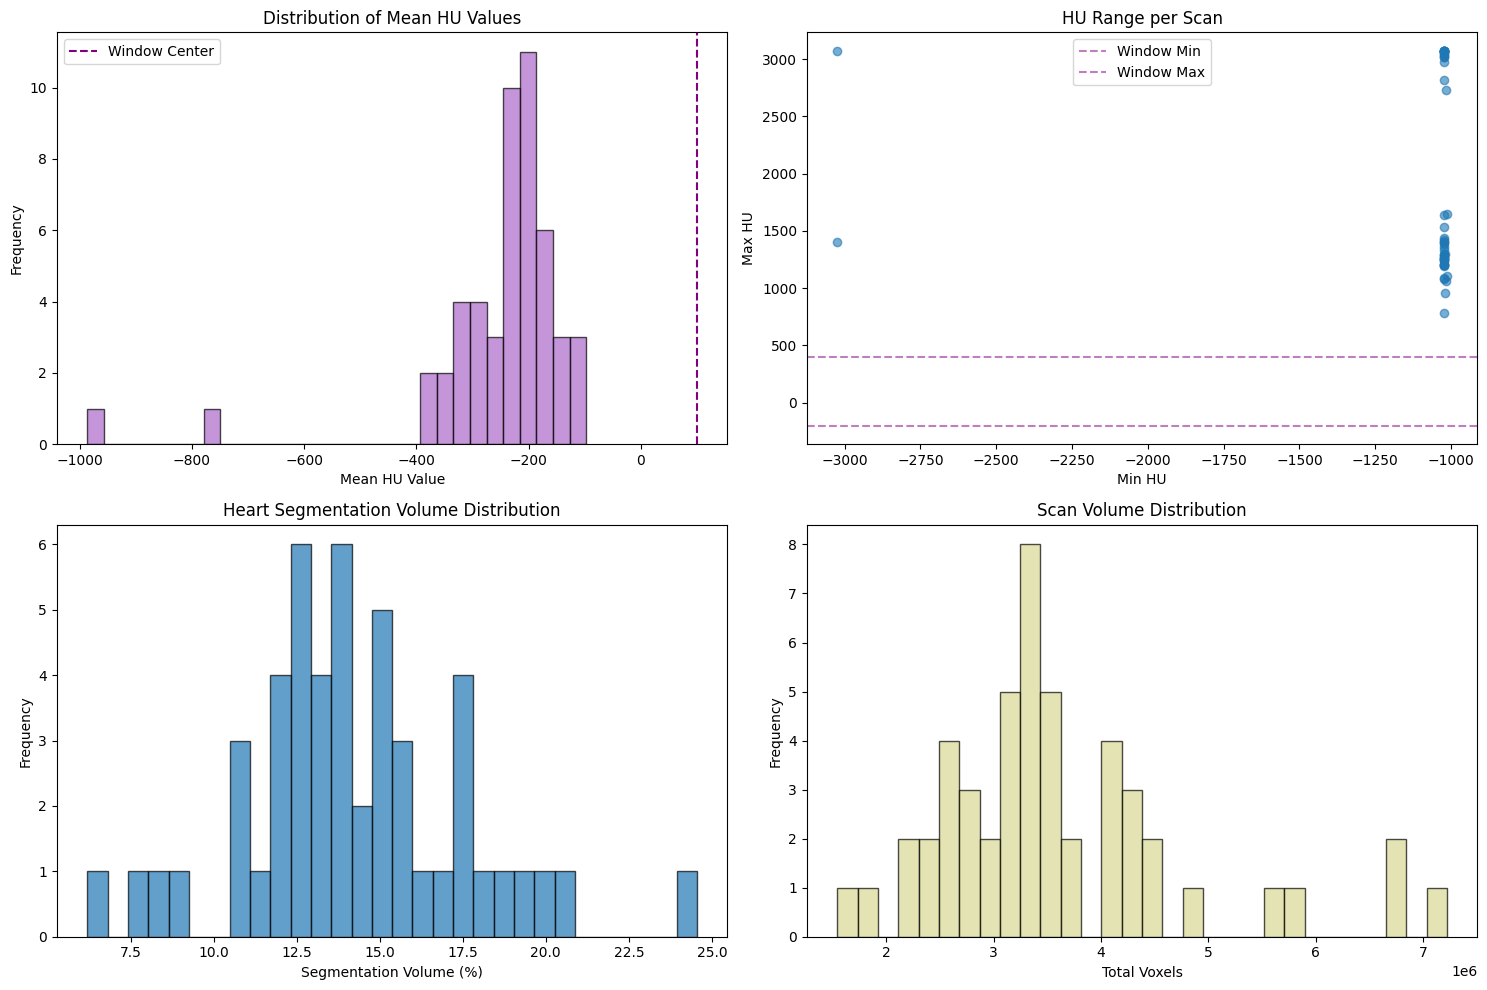


Key Statistics:
Mean segmentation volume: 14.23% of scan volume
Scans with segmentation: 50 / 50


In [5]:
# Visualize HU distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# HU distribution
axes[0, 0].hist(stats_df['hu_mean'], bins=30, alpha=0.7, color="#ab68c8", edgecolor='black')
axes[0, 0].axvline(config.PRIMARY_WINDOW_CENTER, color='purple', linestyle='--', label='Window Center')
axes[0, 0].set_xlabel('Mean HU Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Mean HU Values')
axes[0, 0].legend()

# HU range
axes[0, 1].scatter(stats_df['hu_min'], stats_df['hu_max'], alpha=0.6)
axes[0, 1].axhline(config.HU_MIN, color='purple', linestyle='--', alpha=0.5, label='Window Min')
axes[0, 1].axhline(config.HU_MAX, color='purple', linestyle='--', alpha=0.5, label='Window Max')
axes[0, 1].set_xlabel('Min HU')
axes[0, 1].set_ylabel('Max HU')
axes[0, 1].set_title('HU Range per Scan')
axes[0, 1].legend()

# Segmentation ratio
axes[1, 0].hist(stats_df['seg_ratio'] * 100, bins=30, alpha=0.7, color='#1f77b4',  edgecolor='black')
axes[1, 0].set_xlabel('Segmentation Volume (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Heart Segmentation Volume Distribution')

# Volume shape distribution
volume_sizes = [np.prod(eval(shape) if isinstance(shape, str) else shape) for shape in stats_df['shape']]
axes[1, 1].hist(volume_sizes, bins=30, alpha=0.7, color='#d9d893', edgecolor='black')
axes[1, 1].set_xlabel('Total Voxels')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Scan Volume Distribution')

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'dataset_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey Statistics:")
print(f"Mean segmentation volume: {stats_df['seg_ratio'].mean()*100:.2f}% of scan volume")
print(f"Scans with segmentation: {stats_df['has_segmentation'].sum()} / {len(stats_df)}")

## 3. HU Windowing for Cardiac CT

Original HU range: [-1024.0, 3071.0]
Window 1 range: [0.000, 1.000] (C=40, W=400)
Window 2 range: [0.000, 1.000] (C=100, W=600)


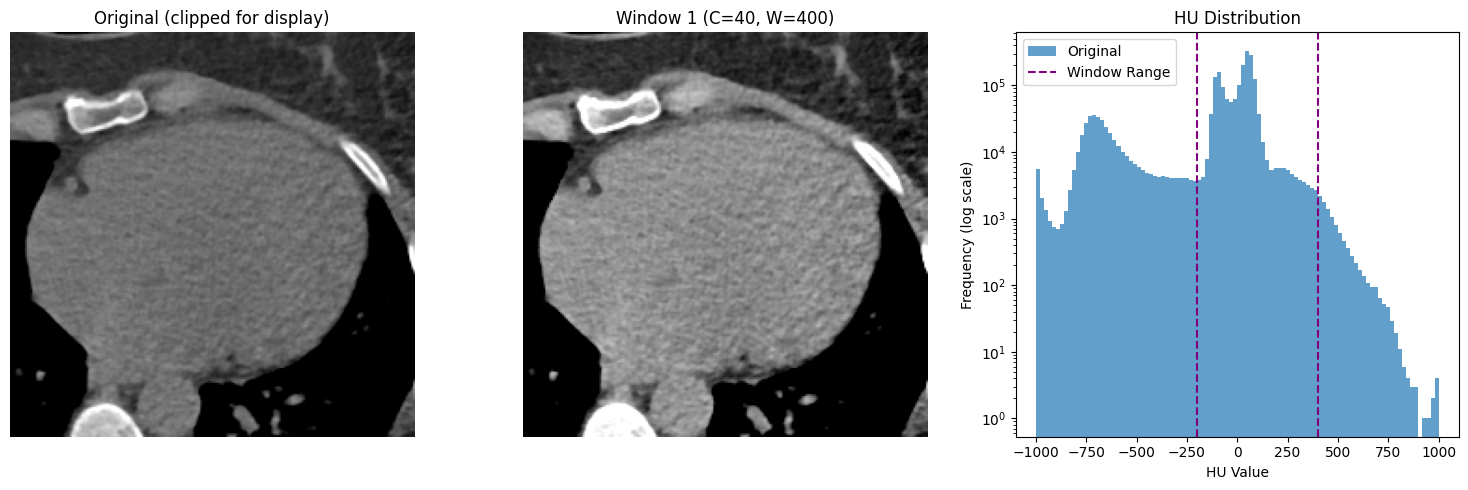

In [6]:
def apply_hu_windowing(image_array, window_center=100, window_width=600):
    """
    Apply HU windowing to cardiac CT images.
    
    Cardiac CT optimal window:
    - Center: 100 HU (cardiac tissue)
    - Width: 600 HU (captures soft tissue, vessels, calcification)
    - Range: [-200, 400] HU
    
    Args:
        image_array: CT image array in HU values
        window_center: Window center in HU
        window_width: Window width in HU
        
    Returns:
        Windowed and normalized array [0, 1]
    """
    min_hu = window_center - (window_width // 2)
    max_hu = window_center + (window_width // 2)
    
    # Clip to window range
    windowed = np.clip(image_array, min_hu, max_hu)
    
    # Normalize to [0, 1]
    windowed = (windowed - min_hu) / (max_hu - min_hu)
    
    return windowed.astype(np.float32)


def apply_multi_windowing(image_array, window_pairs):
    """
    Apply multiple HU windows and stack them as channels.

    Args:
        image_array: CT image array in HU values
        window_pairs: List of (center, width) tuples or dicts
    
    Returns:
        Stacked array with shape (C, D, H, W) in [0, 1]
    """
    channels = []
    for item in window_pairs:
        if isinstance(item, dict):
            center = item["center"]
            width = item["width"]
        else:
            center, width = item
        channels.append(apply_hu_windowing(image_array, center, width))
    return np.stack(channels, axis=0).astype(np.float32)


# Test HU windowing
test_scan = all_valid_scans[0]
test_img_path = config.DATA_DIR / test_scan / f"{test_scan}_img.nii.gz"
test_img_sitk = sitk.ReadImage(str(test_img_path))
test_img = sitk.GetArrayFromImage(test_img_sitk)

# Apply windowing
if config.USE_MULTI_WINDOW:
    windowed_img = apply_multi_windowing(test_img, config.WINDOW_PAIRS)
    print(f"Original HU range: [{test_img.min():.1f}, {test_img.max():.1f}]")
    for idx, item in enumerate(config.WINDOW_PAIRS):
        if isinstance(item, dict):
            center = item["center"]
            width = item["width"]
        else:
            center, width = item
        print(f"Window {idx+1} range: [{windowed_img[idx].min():.3f}, {windowed_img[idx].max():.3f}] (C={center}, W={width})")
else:
    windowed_img = apply_hu_windowing(test_img, config.PRIMARY_WINDOW_CENTER, config.PRIMARY_WINDOW_WIDTH)
    print(f"Original HU range: [{test_img.min():.1f}, {test_img.max():.1f}]")
    print(f"Windowed range: [{windowed_img.min():.3f}, {windowed_img.max():.3f}]")
    print(f"Window applied: Center={config.PRIMARY_WINDOW_CENTER} HU, Width={config.PRIMARY_WINDOW_WIDTH} HU")

# Visualize windowing effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slice_idx = test_img.shape[0] // 2

display_img = windowed_img[0] if config.USE_MULTI_WINDOW else windowed_img

axes[0].imshow(test_img[slice_idx], cmap='gray', vmin=-200, vmax=400)
axes[0].set_title("Original (clipped for display)")
axes[0].axis('off')

axes[1].imshow(display_img[slice_idx], cmap='gray')
if config.USE_MULTI_WINDOW:
    first_item = config.WINDOW_PAIRS[0]
    if isinstance(first_item, dict):
        center = first_item["center"]
        width = first_item["width"]
    else:
        center, width = first_item
    axes[1].set_title(f"Window 1 (C={center}, W={width})")
else:
    axes[1].set_title(f"After Cardiac Windowing (C={config.PRIMARY_WINDOW_CENTER}, W={config.PRIMARY_WINDOW_WIDTH})")
axes[1].axis('off')

axes[2].hist(test_img.flatten(), bins=100, alpha=0.7, label='Original', range=(-1000, 1000))
axes[2].axvline(config.HU_MIN, color='purple', linestyle='--', label='Window Range')
axes[2].axvline(config.HU_MAX, color='purple', linestyle='--')
axes[2].set_xlabel('HU Value')
axes[2].set_ylabel('Frequency (log scale)')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].set_title('HU Distribution')

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'hu_windowing_effect.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Train/Validation/Test Split

        If ratio ≤ 0.1032 → stratum 0

        If between → stratum 1

        If > 0.1256 → stratum 2

        Note: this split based on heart size is specified for segmentation of the heart,but in CAC segmentation i will split based on calcification 

In [7]:
# Create stratified split based on segmentation volume
# This ensures balanced representation of different heart sizes across splits

# Calculate segmentation ratios for all scans (quick version)
scan_seg_ratios = []
for scan_id in tqdm(all_valid_scans, desc="Computing segmentation ratios"):
    seg_path = config.DATA_DIR / scan_id / f"{scan_id}_seg.nii.gz"
    try:
        seg_sitk = sitk.ReadImage(str(seg_path))
        seg_array = sitk.GetArrayFromImage(seg_sitk)
        seg_ratio = (seg_array > 0).sum() / seg_array.size
        scan_seg_ratios.append(seg_ratio)
    except:
        scan_seg_ratios.append(0.0)

# Create stratification bins (tertiles)
seg_ratios_array = np.array(scan_seg_ratios)
bins = np.percentile(seg_ratios_array[seg_ratios_array > 0], [33, 67])
strata = np.digitize(seg_ratios_array, bins)

print(f"Stratification bins: {bins}")
print(f"Stratum distribution: {np.bincount(strata)}")

# Perform stratified split
train_val_scans, test_scans, train_val_strata, test_strata = train_test_split(
    all_valid_scans, strata, 
    test_size=config.TEST_RATIO, 
    stratify=strata, 
    random_state=42
)

train_scans, val_scans = train_test_split(
    train_val_scans,
    test_size=config.VAL_RATIO / (config.TRAIN_RATIO + config.VAL_RATIO),
    stratify=train_val_strata,
    random_state=42
)

print(f"\nDataset Split:")
print(f"Train: {len(train_scans)} scans ({len(train_scans)/len(all_valid_scans)*100:.1f}%)")
print(f"Val:   {len(val_scans)} scans ({len(val_scans)/len(all_valid_scans)*100:.1f}%)")
print(f"Test:  {len(test_scans)} scans ({len(test_scans)/len(all_valid_scans)*100:.1f}%)")

# Save split to file
split_info = {
    'train': train_scans,
    'val': val_scans,
    'test': test_scans
}

with open(config.OUTPUT_DIR / 'data_split.json', 'w') as f:
    json.dump(split_info, f, indent=2)
    
print(f"\nData split saved to: {config.OUTPUT_DIR / 'data_split.json'}")

Computing segmentation ratios: 100%|██████████| 50/50 [00:00<00:00, 89.50it/s] 

Stratification bins: [0.12657875 0.15149127]
Stratum distribution: [17 16 17]

Dataset Split:
Train: 34 scans (68.0%)
Val:   8 scans (16.0%)
Test:  8 scans (16.0%)

Data split saved to: C:\CT_Datasets\preprocessed_data\data_split.json


## 5. Data Augmentation

Data augmentation for 3D cardiac segmentation:
- **Spatial transforms** (applied to image + mask jointly):
  - `RandAffine` (prob=0.5): Small rotations (±5° x/y, ±10° z), translations (5, 5, 2 voxels), and scaling (±10% in-plane, ±5% depth)
  - `Rand3DElastic` (prob=0.3): 3D elastic deformation with sigma_range=(5,7) and magnitude_range=(1,2) for anatomical variability

- **Intensity transforms** (applied to image only):- **Optimized for segmentation**: All spatial transforms preserve image-mask alignment; small translation/scaling magnitudes keep the heart within anatomical bounds and avoid unrealistic displacements.

  - `RandGaussianNoise` (prob=0.2): Additive noise (std=0.01) to simulate scanner noise  - `RandShiftIntensity` (prob=0.3): Additive shift (±0.1) for baseline variation

  - `RandGaussianSmooth` (prob=0.2): Gaussian blur (sigma 0.5-1.0) to simulate reconstruction kernels  - `RandScaleIntensity` (prob=0.3): Multiplicative scaling (±10%) for contrast variation

In [8]:

# Spatial augmentations (image + mask)

train_transforms = Compose([
    # Small rotations, translations, scaling (affine)
    RandAffine(
        prob=0.5,
        rotate_range=(np.pi/36, np.pi/36, np.pi/18),  # ±5° x,y, ±10° z
        translate_range=(5, 5, 2),
        scale_range=(0.1, 0.1, 0.05),
        mode='bilinear',
        padding_mode='border'
    ),

    #  3D elastic deformation
    Rand3DElastic(
        prob=0.3,
        sigma_range=(5, 7),
        magnitude_range=(1, 2),
        mode='bilinear',
        padding_mode='border'
    ),
])


# Intensity augmentations (images only)
intensity_transforms = Compose([
    RandGaussianNoise(prob=0.2, mean=0.0, std=0.01),
    RandGaussianSmooth(prob=0.2, sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)),
    RandScaleIntensity(prob=0.3, factors=0.1),
    RandShiftIntensity(prob=0.3, offsets=0.1),
])

print("Whole-heart augmentation pipeline defined:")
print("- Spatial: affine + 3D elastic deformation")
print("- Intensity: Gaussian noise, smoothing, intensity scaling/shifting")

Whole-heart augmentation pipeline defined:
- Spatial: affine + 3D elastic deformation
- Intensity: Gaussian noise, smoothing, intensity scaling/shifting


Preparing augmentation preview...


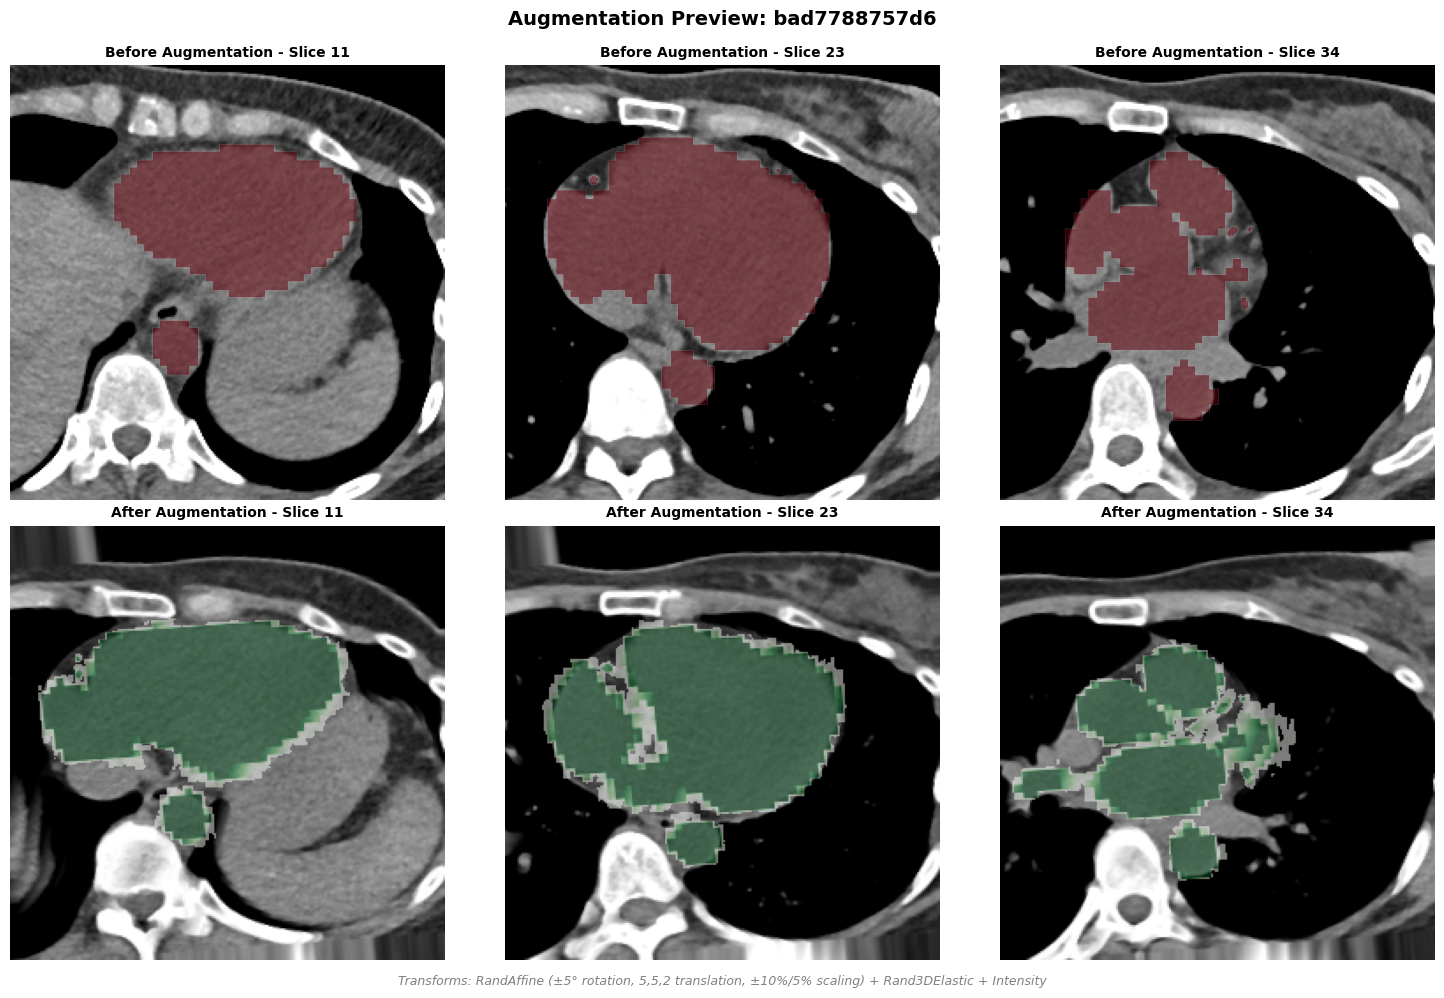

Augmentation preview saved to: C:\CT_Datasets\preprocessed_data\augmentation_preview.png
Red overlay = heart mask | Compare before (top) vs after (bottom) to see spatial/intensity changes


In [9]:
# Augmentation preview: visualize before/after for a sample scan
print('Preparing augmentation preview...')
# Choose a sample scan (prefer a train scan if available)
sample_scan = train_scans[1] if 'train_scans' in globals() and len(train_scans) > 0 else all_valid_scans[0]
img_path = config.DATA_DIR / sample_scan / f"{sample_scan}_img.nii.gz"
seg_path = config.DATA_DIR / sample_scan / f"{sample_scan}_seg.nii.gz"
# Load image and mask
img_sitk = sitk.ReadImage(str(img_path))
seg_sitk = sitk.ReadImage(str(seg_path))
img = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
mask = sitk.GetArrayFromImage(seg_sitk).astype(np.float32)
mask = (mask > 0).astype(np.float32)
# Apply HU windowing consistent with the dataset pipeline
if config.USE_MULTI_WINDOW:
    img_w = apply_multi_windowing(img, config.WINDOW_PAIRS)
else:
    img_w = apply_hu_windowing(img, config.PRIMARY_WINDOW_CENTER, config.PRIMARY_WINDOW_WIDTH)
# Ensure channel dimension
if not config.USE_MULTI_WINDOW:
    img_w = np.expand_dims(img_w, axis=0)
mask_c = np.expand_dims(mask, axis=0)
# Combine image and mask for spatial augmentation (C+1, D, H, W)
combined = np.concatenate([img_w, mask_c], axis=0)
try:
    combined_aug = train_transforms(combined)
    if isinstance(combined_aug, torch.Tensor):
        combined_aug = combined_aug.numpy()
except Exception as e:
    print('Warning: spatial augmentation failed:', e)
    combined_aug = combined
# Split augmented image and mask
n_img_ch = img_w.shape[0]
img_aug = combined_aug[0:n_img_ch]
mask_aug = combined_aug[n_img_ch:n_img_ch+1]
# Apply intensity augmentations to image channels only (catch failures)
try:
    img_aug = intensity_transforms(torch.from_numpy(img_aug)).numpy()
except Exception as e:
    print('Warning: intensity augmentation failed:', e)
# Prepare arrays for visualization
img_before = img_w
mask_before = mask_c
img_after = img_aug
mask_after = mask_aug
# Visualize three representative axial slices (quarter, mid, three-quarter)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
depth = img_before.shape[1]
slices = [depth//4, depth//2, 3*depth//4]
for i, slice_idx in enumerate(slices):
    # Before augmentation with mask overlay
    axes[0, i].imshow(img_before[0, slice_idx], cmap='gray')
    axes[0, i].imshow(mask_before[0, slice_idx], cmap='Reds', alpha=0.5 * (mask_before[0, slice_idx] > 0))
    axes[0, i].set_title(f'Before Augmentation - Slice {slice_idx}', fontsize=10, weight='bold')
    axes[0, i].axis('off')
    
    # After augmentation with mask overlay
    axes[1, i].imshow(img_after[0, slice_idx], cmap='gray')
    axes[1, i].imshow(mask_after[0, slice_idx], cmap='Greens', alpha=0.5 * (mask_after[0, slice_idx] > 0))
   # axes[1, i].imshow(mask_before[0, slice_idx], cmap='Reds', alpha=0.5 * (mask_before[0, slice_idx] > 0))

    axes[1, i].set_title(f'After Augmentation - Slice {slice_idx}', fontsize=10, weight='bold')
    axes[1, i].axis('off')

# Add text annotation explaining the transforms
fig.text(0.5, 0.98, f'Augmentation Preview: {sample_scan}', 
         ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.02, 
         'Transforms: RandAffine (±5° rotation, 5,5,2 translation, ±10%/5% scaling) + Rand3DElastic + Intensity',
         ha='center', fontsize=9, style='italic', color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
out_path = config.OUTPUT_DIR / 'augmentation_preview.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Augmentation preview saved to: {out_path}')
print(f'Red overlay = heart mask | Compare before (top) vs after (bottom) to see spatial/intensity changes')

        this is repeated cell ,but         
        i uncommented this line 
        axes[1, i].imshow(mask_before[0, slice_idx], cmap='Reds', alpha=0.5 * (mask_before[0, slice_idx] > 0))
        to see the two masks overlay and sense the difference between before and after augmentation.

Preparing augmentation preview...


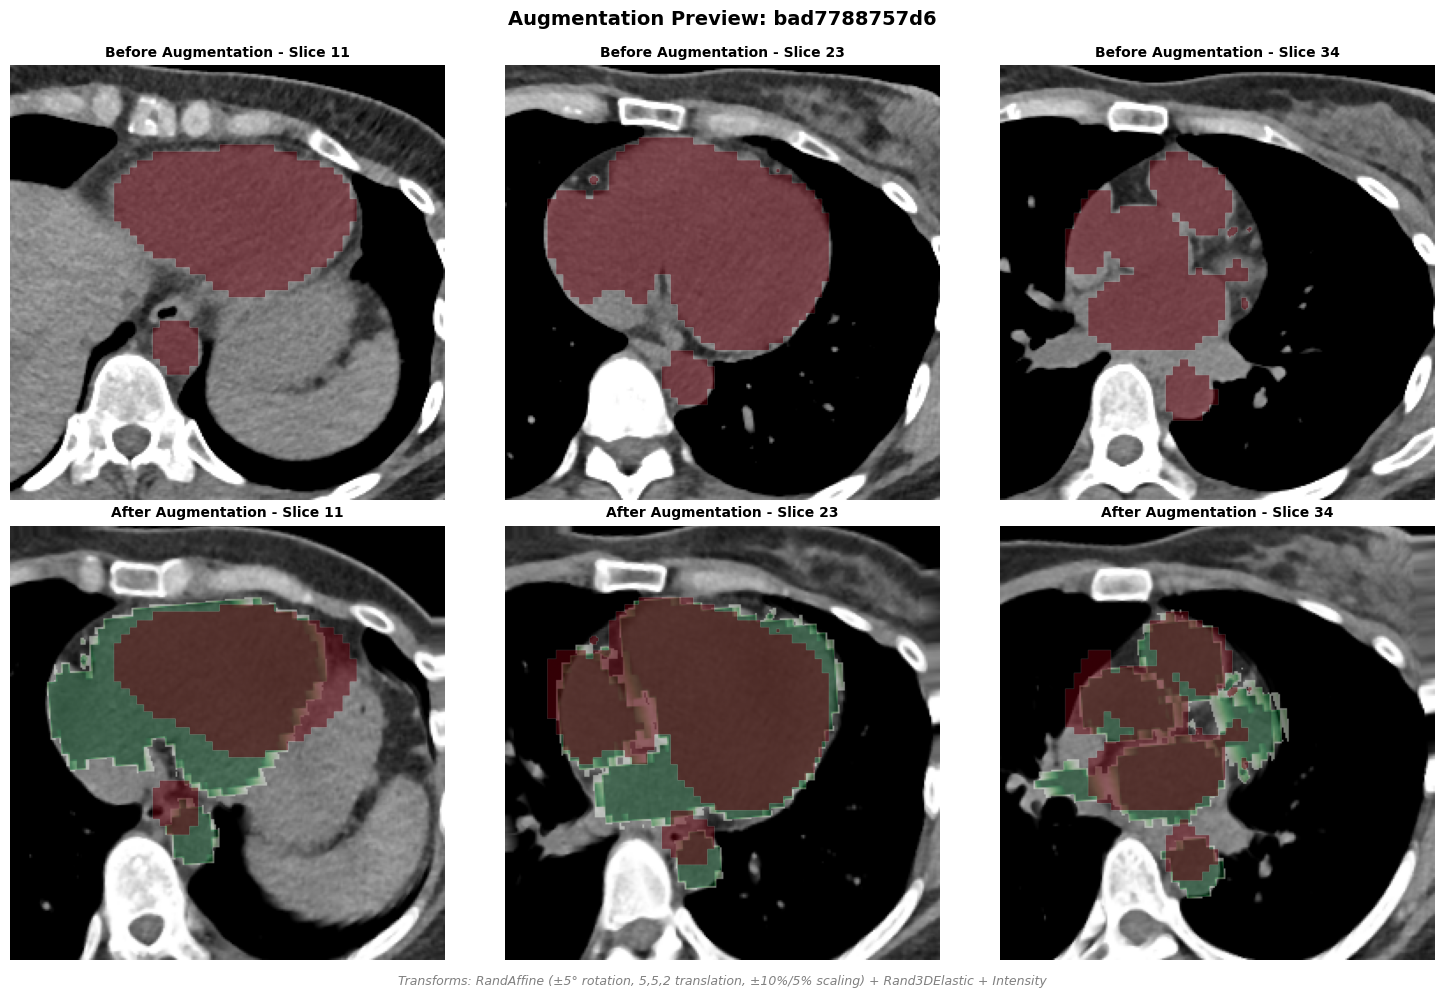

Augmentation preview saved to: C:\CT_Datasets\preprocessed_data\augmentation_preview.png
Red overlay = heart mask | Compare before (top) vs after (bottom) with overlay to see spatial/intensity changes


In [10]:
# Augmentation preview: visualize before/after for a sample scan
print('Preparing augmentation preview...')
# Choose a sample scan (prefer a train scan if available)
sample_scan = train_scans[1] if 'train_scans' in globals() and len(train_scans) > 0 else all_valid_scans[0]
img_path = config.DATA_DIR / sample_scan / f"{sample_scan}_img.nii.gz"
seg_path = config.DATA_DIR / sample_scan / f"{sample_scan}_seg.nii.gz"
# Load image and mask
img_sitk = sitk.ReadImage(str(img_path))
seg_sitk = sitk.ReadImage(str(seg_path))
img = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
mask = sitk.GetArrayFromImage(seg_sitk).astype(np.float32)
mask = (mask > 0).astype(np.float32)
# Apply HU windowing consistent with the dataset pipeline
if config.USE_MULTI_WINDOW:
    img_w = apply_multi_windowing(img, config.WINDOW_PAIRS)
else:
    img_w = apply_hu_windowing(img, config.PRIMARY_WINDOW_CENTER, config.PRIMARY_WINDOW_WIDTH)
# Ensure channel dimension
if not config.USE_MULTI_WINDOW:
    img_w = np.expand_dims(img_w, axis=0)
mask_c = np.expand_dims(mask, axis=0)
# Combine image and mask for spatial augmentation (C+1, D, H, W)
combined = np.concatenate([img_w, mask_c], axis=0)
try:
    combined_aug = train_transforms(combined)
    if isinstance(combined_aug, torch.Tensor):
        combined_aug = combined_aug.numpy()
except Exception as e:
    print('Warning: spatial augmentation failed:', e)
    combined_aug = combined
# Split augmented image and mask
n_img_ch = img_w.shape[0]
img_aug = combined_aug[0:n_img_ch]
mask_aug = combined_aug[n_img_ch:n_img_ch+1]
# Apply intensity augmentations to image channels only (catch failures)
try:
    img_aug = intensity_transforms(torch.from_numpy(img_aug)).numpy()
except Exception as e:
    print('Warning: intensity augmentation failed:', e)
# Prepare arrays for visualization
img_before = img_w
mask_before = mask_c
img_after = img_aug
mask_after = mask_aug
# Visualize three representative axial slices (quarter, mid, three-quarter)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
depth = img_before.shape[1]
slices = [depth//4, depth//2, 3*depth//4]
for i, slice_idx in enumerate(slices):
    # Before augmentation with mask overlay
    axes[0, i].imshow(img_before[0, slice_idx], cmap='gray')
    axes[0, i].imshow(mask_before[0, slice_idx], cmap='Reds', alpha=0.5 * (mask_before[0, slice_idx] > 0))
    axes[0, i].set_title(f'Before Augmentation - Slice {slice_idx}', fontsize=10, weight='bold')
    axes[0, i].axis('off')
    
    # After augmentation with mask overlay
    axes[1, i].imshow(img_after[0, slice_idx], cmap='gray')
    axes[1, i].imshow(mask_after[0, slice_idx], cmap='Greens', alpha=0.5 * (mask_after[0, slice_idx] > 0))
    axes[1, i].imshow(mask_before[0, slice_idx], cmap='Reds', alpha=0.5 * (mask_before[0, slice_idx] > 0))

    axes[1, i].set_title(f'After Augmentation - Slice {slice_idx}', fontsize=10, weight='bold')
    axes[1, i].axis('off')

# Add text annotation explaining the transforms
fig.text(0.5, 0.98, f'Augmentation Preview: {sample_scan}', 
         ha='center', fontsize=14, weight='bold')
fig.text(0.5, 0.02, 
         'Transforms: RandAffine (±5° rotation, 5,5,2 translation, ±10%/5% scaling) + Rand3DElastic + Intensity',
         ha='center', fontsize=9, style='italic', color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
out_path = config.OUTPUT_DIR / 'augmentation_preview.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Augmentation preview saved to: {out_path}')
print(f'Red overlay = heart mask | Compare before (top) vs after (bottom) with overlay to see spatial/intensity changes')

## 6. Efficient Data Loader

Custom PyTorch Dataset optimized for cardiac CT segmentation:
- Memory-efficient loading with caching option
- HU windowing applied on-the-fly
- Data augmentation for training set
- Handles variable-sized volumes
- Supports batch processing
- **Sampling strategy:** training uses a custom `StratifiedBatchSampler` that groups scans by heart-size tertile and round-robins across groups when filling each batch, so every batch contains a mix of small/medium/large hearts. Each scan is seen exactly once per epoch (no replacement). A computed `pos_weight` is passed to `BCEWithLogitsLoss` to handle voxel-level imbalance (background >> heart voxels).

> **Why not `WeightedRandomSampler`?** Every COCA scan contains a heart — coverage varies only modestly (~3–10 % of voxels). `WeightedRandomSampler` with `replacement=True` on only 27 train scans would repeat some scans several times per epoch while skipping others, destroying the stratified balance and causing overfitting. It also operates at the wrong level: the real class imbalance is voxel-level (heart ≈ 3–5 %), which `pos_weight` already corrects.


In [11]:
class CardiacCTDataset(Dataset):
    """
    Custom Dataset for Cardiac CT Segmentation.
    
    Features:
    - On-the-fly HU windowing
    - Optional data augmentation
    - Memory-efficient loading
    - Returns both image and segmentation mask
    """
    
    def __init__(self, scan_ids, data_dir, config, augment=False, cache=False):
        """
        Args:
            scan_ids: List of scan IDs to include
            data_dir: Path to data directory
            config: Configuration object
            augment: Whether to apply data augmentation
            cache: Whether to cache loaded volumes in memory
        """
        self.scan_ids = scan_ids
        self.data_dir = Path(data_dir)
        self.config = config
        self.augment = augment
        self.cache = cache
        self.cached_data = {} if cache else None
        
        print(f"Initialized CardiacCTDataset with {len(scan_ids)} scans (augment={augment}, cache={cache})")
    
    def __len__(self):
        return len(self.scan_ids)
    
    def __getitem__(self, idx):
        scan_id = self.scan_ids[idx]
        
        # Check cache first
        if self.cache and scan_id in self.cached_data:
            image, mask = self.cached_data[scan_id]
        else:
            # Load image and mask
            img_path = self.data_dir / scan_id / f"{scan_id}_img.nii.gz"
            seg_path = self.data_dir / scan_id / f"{scan_id}_seg.nii.gz"
            
            # Read with SimpleITK
            img_sitk = sitk.ReadImage(str(img_path))
            seg_sitk = sitk.ReadImage(str(seg_path))
            
            # Convert to numpy
            image = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
            mask = sitk.GetArrayFromImage(seg_sitk).astype(np.float32)
            
            # Apply HU windowing to image
            if self.config.USE_MULTI_WINDOW:
                image = apply_multi_windowing(image, self.config.WINDOW_PAIRS)
            else:
                image = apply_hu_windowing(
                    image,
                    self.config.PRIMARY_WINDOW_CENTER,
                    self.config.PRIMARY_WINDOW_WIDTH
                )
            
            # Ensure mask is binary
            mask = (mask > 0).astype(np.float32)
            
            # Cache if enabled
            if self.cache:
                self.cached_data[scan_id] = (image.copy(), mask.copy())
        
        # Add channel dimension if single-window
        if not self.config.USE_MULTI_WINDOW:
            image = np.expand_dims(image, axis=0)
        
        # Mask channel: (D, H, W) -> (1, D, H, W)
        mask = np.expand_dims(mask, axis=0)
        
        # Apply augmentation if training
        if self.augment:
            # Combine for spatial augmentation
            combined = np.concatenate([image, mask], axis=0)  # (C+1, D, H, W)
            image_channels = image.shape[0]
            
            # Apply spatial transforms to both (use numpy input; handle torch outputs)
            try:
                combined_aug = train_transforms(combined)
                if isinstance(combined_aug, torch.Tensor):
                    combined_aug = combined_aug.numpy()
                image = combined_aug[0:image_channels]
                mask = combined_aug[image_channels:image_channels+1]
            except Exception:
                # If augmentation fails, use original
                pass
            
            # Apply intensity transforms only to image
            image_tensor = torch.from_numpy(image)
            try:
                image = intensity_transforms(image_tensor).numpy()
            except:
                pass
        
        # Convert to torch tensors
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float()
        
        # Ensure mask is binary after augmentation
        mask = (mask > 0.5).float()
        
        return {
            'image': image,
            'mask': mask,
            'scan_id': scan_id
        }

# Create datasets
train_dataset = CardiacCTDataset(train_scans, config.DATA_DIR, config, augment=True, cache=False)
val_dataset = CardiacCTDataset(val_scans, config.DATA_DIR, config, augment=False, cache=False)
test_dataset = CardiacCTDataset(test_scans, config.DATA_DIR, config, augment=False, cache=False)

print(f"\nDatasets created:")
print(f"Train: {len(train_dataset)} samples (with augmentation)")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")

Initialized CardiacCTDataset with 34 scans (augment=True, cache=False)
Initialized CardiacCTDataset with 8 scans (augment=False, cache=False)
Initialized CardiacCTDataset with 8 scans (augment=False, cache=False)

Datasets created:
Train: 34 samples (with augmentation)
Val:   8 samples
Test:  8 samples


In [ ]:
from torch.utils.data import Sampler

# Custom collate function for variable-sized volumes
def collate_fn(batch):
    """
    Custom collate function to handle variable-sized 3D volumes.
    Returns a list of samples instead of stacking them.
    """
    return batch


# ── StratifiedBatchSampler ────────────────────────────────────────────────────
class StratifiedBatchSampler(Sampler):
    """
    Yields batches in which each heart-size tertile is equally represented.

    Why better than WeightedRandomSampler for this task
    ---------------------------------------------------
    • All COCA scans *contain* a heart — coverage varies only ~3-10 % of voxels,
      so scan-level reweighting barely changes the per-batch foreground fraction.
    • WeightedRandomSampler(replacement=True) on 27 scans repeats some scans
      5× per epoch and skips others entirely, destroying stratification.
    • The real imbalance is voxel-level (heart ≈ 3-5 %), handled by pos_weight
      in BCEWithLogitsLoss — not by scan-level resampling.

    This sampler round-robins across tertile groups (small / medium / large
    heart) so every batch has diverse gradient signal and every scan is seen
    exactly once per epoch.
    """

    def __init__(self, scan_ids, strata_map, batch_size, drop_last=False):
        """
        Args:
            scan_ids:   ordered list of scan IDs in the dataset
            strata_map: dict {scan_id → tertile_label}
            batch_size: number of volumes per batch
            drop_last:  drop the final incomplete batch
        """
        self.batch_size = batch_size
        self.drop_last  = drop_last

        # Group dataset indices by their stratum
        groups = {}
        for i, sid in enumerate(scan_ids):
            g = strata_map[sid]
            groups.setdefault(g, []).append(i)
        self.groups   = groups
        self.n_groups = len(groups)

    def __iter__(self):
        # Shuffle within each group independently each epoch
        shuffled = {g: list(np.random.permutation(idxs))
                    for g, idxs in self.groups.items()}
        pointers = {g: 0 for g in shuffled}

        batch = []
        while True:
            all_exhausted = True
            for g in sorted(shuffled):              # round-robin across strata
                if pointers[g] < len(shuffled[g]):
                    batch.append(shuffled[g][pointers[g]])
                    pointers[g] += 1
                    all_exhausted = False
                    if len(batch) == self.batch_size:
                        yield batch
                        batch = []
            if all_exhausted:
                break

        if batch and not self.drop_last:
            yield batch

    def __len__(self):
        total = sum(len(v) for v in self.groups.values())
        if self.drop_last:
            return total // self.batch_size
        return (total + self.batch_size - 1) // self.batch_size


# ── Build strata map for train scans from the split cell's outputs ────────────
# `all_valid_scans`, `scan_seg_ratios`, `bins` are in the kernel namespace
# from the stratified-split cell above.
scan_to_stratum = {sid: int(np.digitize(ratio, bins))
                   for sid, ratio in zip(all_valid_scans, scan_seg_ratios)}
train_strata_map = {sid: scan_to_stratum[sid] for sid in train_scans}

print("Train scan tertile distribution:")
from collections import Counter
cnt = Counter(train_strata_map.values())
for g in sorted(cnt):
    label = {0: "small", 1: "medium", 2: "large"}.get(g, str(g))
    print(f"  Tertile {g} ({label:>6} heart): {cnt[g]} scans")

# ── Compute pos_weight for BCEWithLogitsLoss (voxel-level imbalance) ─────────
# This is the primary class-imbalance correction:
#   pos_weight = total_background_voxels / total_heart_voxels  (~20-30×)
# It makes the BCE term give equal effective gradient mass to the rare
# foreground class, complementing the structural Dice loss.
print("\nComputing pos_weight from train segmentation masks…", end=" ", flush=True)
total_heart_voxels, total_voxels = 0, 0
for scan_id in train_scans:
    seg_path = config.DATA_DIR / scan_id / f"{scan_id}_seg.nii.gz"
    try:
        seg_array = sitk.GetArrayFromImage(sitk.ReadImage(str(seg_path)))
        total_heart_voxels += int((seg_array > 0).sum())
        total_voxels       += seg_array.size
    except Exception as e:
        print(f"\nWarning: could not read {scan_id}: {e}")

if total_heart_voxels > 0:
    total_bg   = total_voxels - total_heart_voxels
    pos_weight = torch.tensor(total_bg / total_heart_voxels, dtype=torch.float32)
else:
    pos_weight = torch.tensor(1.0, dtype=torch.float32)

print(f"done.\npos_weight = {pos_weight.item():.1f}  "
      f"(bg/heart voxel ratio across {len(train_scans)} train scans)")

# ── Data loaders ──────────────────────────────────────────────────────────────
train_sampler = StratifiedBatchSampler(
    train_scans, train_strata_map,
    batch_size=config.BATCH_SIZE, drop_last=False
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,        # replaces batch_size + sampler
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

print(f"\nData loaders created:")
print(f"Train: {len(train_loader)} batches "
      f"(batch_size={config.BATCH_SIZE}, StratifiedBatchSampler)")
print(f"Val  : {len(val_loader)} batches (batch_size={config.BATCH_SIZE})")
print(f"Test : {len(test_loader)} batches (batch_size=1)")
print(f"\nNote: use BCEWithLogitsLoss(pos_weight=pos_weight) during training.")


Computing per-scan sampling weights for train set...
Sample weights computed (train scans=34).
Computed pos_weight for BCEWithLogitsLoss: 6.361

Data loaders created:
Train: 9 batches (batch_size=4) - using WeightedRandomSampler
Val:   2 batches (batch_size=4)
Test:  8 batches (batch_size=1)


Testing data loader...


c:\CT_Datasets\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Batch size: 4
First sample:
  - Image shape: torch.Size([2, 46, 234, 234])
  - Mask shape: torch.Size([1, 46, 234, 234])
  - Scan ID: 13f9f43c851e
  - Image range: [0.000, 1.000]
  - Mask unique values: tensor([0., 1.])
  - Heart pixels: 385551 / 2518776 (15.31%)


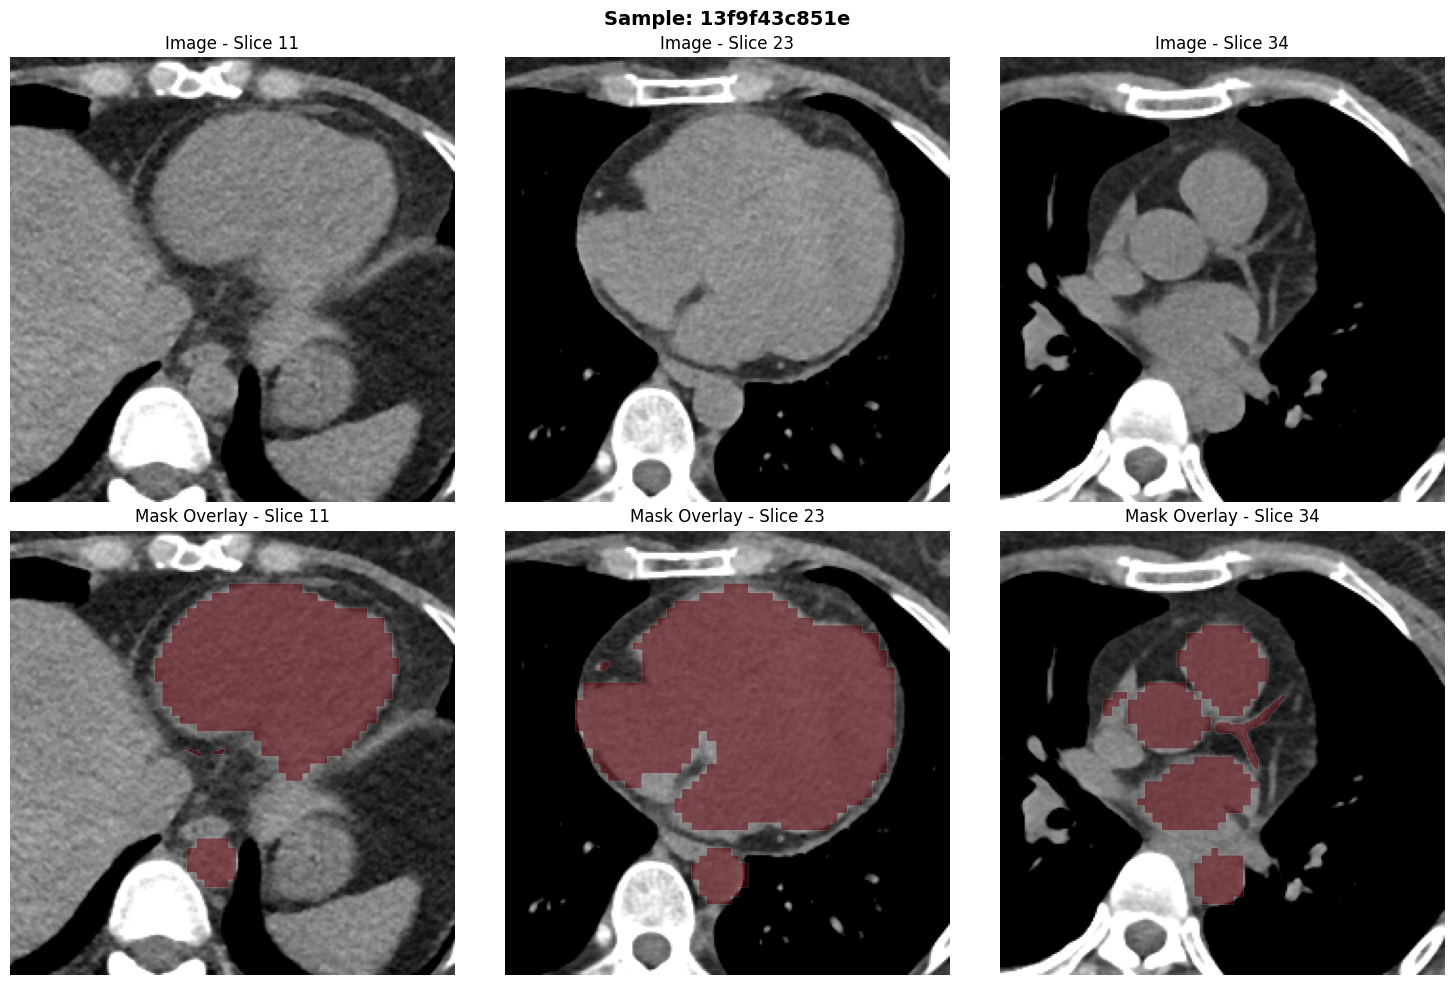


✓ Data loader working correctly!


In [ ]:
# Test data loader — verify StratifiedBatchSampler produces diverse batches
print("Testing data loader…")
sample_batch = next(iter(train_loader))

print(f"\nBatch size: {len(sample_batch)}")
print("Scan IDs and heart-size tertile in this batch:")
for s in sample_batch:
    sid = s['scan_id']
    t   = train_strata_map.get(sid, "?")
    lbl = {0: "small", 1: "medium", 2: "large"}.get(t, str(t))
    hrt = s['mask'].sum().item()
    tot = s['mask'].numel()
    print(f"  {sid[:14]}  tertile={t} ({lbl:>6})  "
          f"heart={hrt:.0f}/{tot} ({hrt/tot*100:.2f}%)")

print(f"\nFirst sample:")
print(f"  Image shape : {sample_batch[0]['image'].shape}")
print(f"  Mask shape  : {sample_batch[0]['mask'].shape}")
print(f"  Image range : [{sample_batch[0]['image'].min():.3f}, {sample_batch[0]['image'].max():.3f}]")

# Visualize a sample
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sample = sample_batch[0]
if config.USE_MULTI_WINDOW:
    image_vol = sample['image'][0].numpy()
else:
    image_vol = sample['image'].squeeze().numpy()
mask_vol = sample['mask'].squeeze().numpy()

slices = [image_vol.shape[0]//4, image_vol.shape[0]//2, 3*image_vol.shape[0]//4]
for i, slice_idx in enumerate(slices):
    axes[0, i].imshow(image_vol[slice_idx], cmap='gray')
    axes[0, i].set_title(f'Image — Slice {slice_idx}')
    axes[0, i].axis('off')

    axes[1, i].imshow(image_vol[slice_idx], cmap='gray')
    axes[1, i].imshow(mask_vol[slice_idx], cmap='Reds',
                      alpha=0.5 * (mask_vol[slice_idx] > 0))
    axes[1, i].set_title(f'Mask Overlay — Slice {slice_idx}')
    axes[1, i].axis('off')

t_lbl = {0: "small", 1: "medium", 2: "large"}.get(
    train_strata_map.get(sample['scan_id'], 0), "?")
plt.suptitle(f"Sample: {sample['scan_id']}  (tertile: {t_lbl} heart)",
             fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'sample_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Data loader working correctly!")


## 7. Comprehensive Dataset Statistics

Generate detailed statistics for the preprocessed dataset including:
- Volume size distributions
- HU value distributions (both original and windowed/normalized)
- Segmentation coverage
- Split statistics
- Class balance analysis
- Windowed mean intensity distributions (showing actual model input statistics)

In [14]:
# Compute comprehensive statistics
def compute_dataset_statistics(scan_list, split_name):
    """Compute statistics for a dataset split."""
    stats = {
        'split': split_name,
        'n_scans': len(scan_list),
        'volumes': [],
        'shapes': [],
        'spacings': [],
        'seg_volumes': [],
        'seg_ratios': [],
        'hu_stats': []
    }
    
    for scan_id in tqdm(scan_list, desc=f"Analyzing {split_name}"):
        img_path = config.DATA_DIR / scan_id / f"{scan_id}_img.nii.gz"
        seg_path = config.DATA_DIR / scan_id / f"{scan_id}_seg.nii.gz"
        
        try:
            # Load image
            img_sitk = sitk.ReadImage(str(img_path))
            img_array = sitk.GetArrayFromImage(img_sitk)
            
            # Load segmentation
            seg_sitk = sitk.ReadImage(str(seg_path))
            seg_array = sitk.GetArrayFromImage(seg_sitk)
            
            # Collect statistics
            stats['volumes'].append(img_array.size)
            stats['shapes'].append(img_array.shape)
            stats['spacings'].append(img_sitk.GetSpacing())
            stats['seg_volumes'].append((seg_array > 0).sum())
            stats['seg_ratios'].append((seg_array > 0).sum() / seg_array.size)
            stats['hu_stats'].append({
                'mean': float(img_array.mean()),
                'std': float(img_array.std()),
                'min': float(img_array.min()),
                'max': float(img_array.max())
            })
        except Exception as e:
            print(f"Error processing {scan_id}: {e}")
    
    return stats

# statistics for all splits
print("Computing comprehensive dataset statistics...")
train_stats = compute_dataset_statistics(train_scans[:50], 'Train')  
val_stats = compute_dataset_statistics(val_scans, 'Val')
test_stats = compute_dataset_statistics(test_scans, 'Test')

all_stats = [train_stats, val_stats, test_stats]

Computing comprehensive dataset statistics...


Analyzing Test: 100%|██████████| 8/8 [00:00<00:00,  9.32it/s]


Computing windowed statistics for all splits...
NOTE: These are post-preprocessing values (after HU windowing & normalization)


Computing windowed stats for Test: 100%|██████████| 8/8 [00:01<00:00,  5.56it/s]
C:\Users\Amira\AppData\Local\Temp\ipykernel_1320\693997372.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.99])


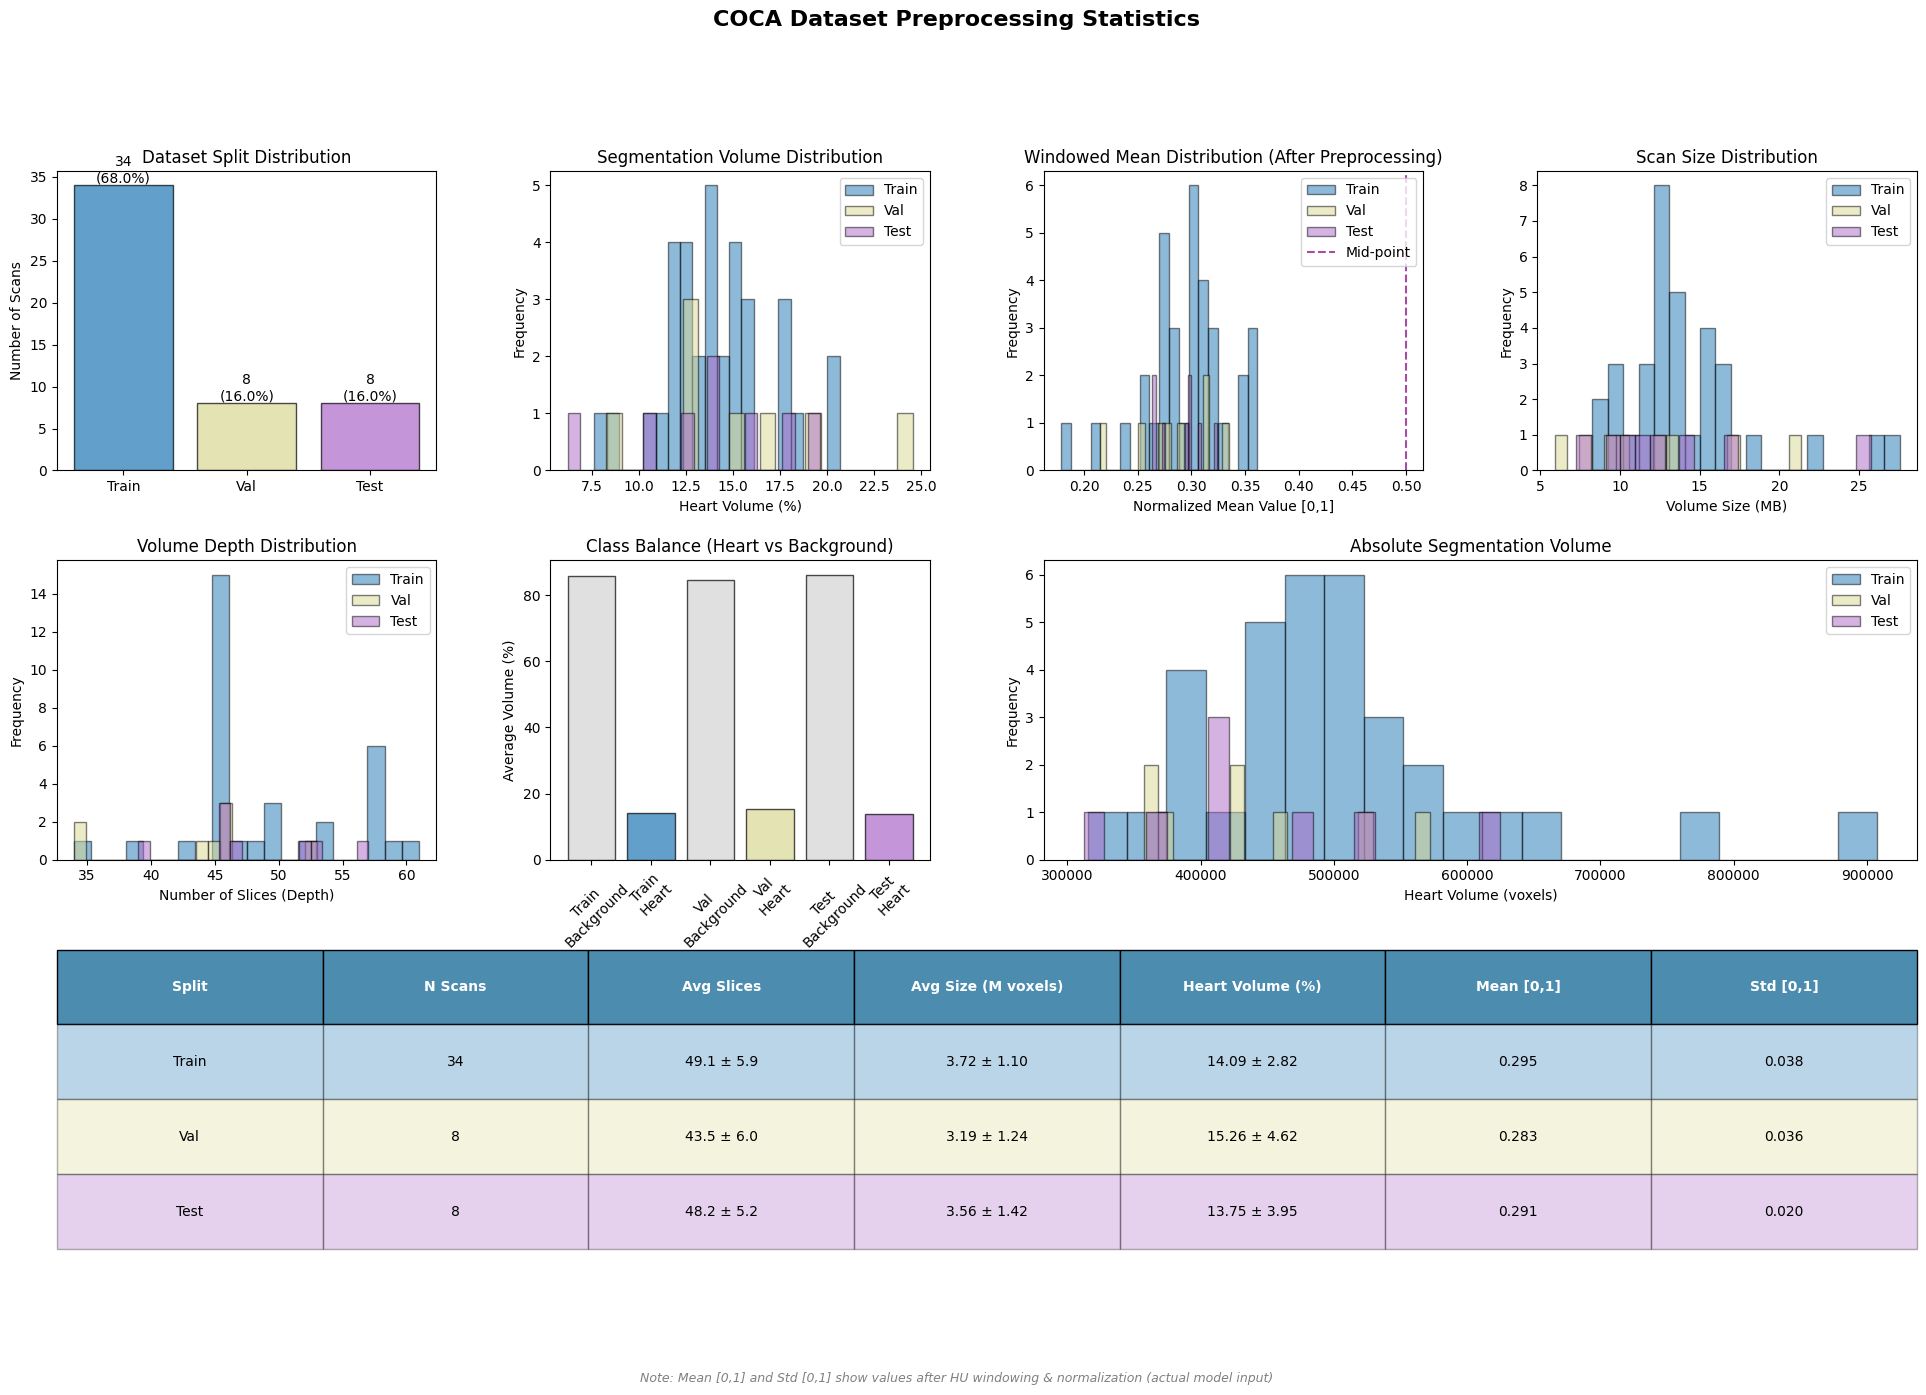


✓ Comprehensive statistics generated!
   - Mean/Std values show windowed/normalized data (after preprocessing)
   - Saved to: comprehensive_statistics.png


In [15]:
# windowed statistics for visualization
# This shows the actual normalized [0,1] values that the model will see during training
print("Computing windowed statistics for all splits...")
print("NOTE: These are post-preprocessing values (after HU windowing & normalization)")
windowed_stats = []
for scan_list, split_name in [(train_scans[:50], 'Train'), (val_scans, 'Val'), (test_scans, 'Test')]:
    windowed_means = []
    for scan_id in tqdm(scan_list, desc=f"Computing windowed stats for {split_name}"):
        img_path = config.DATA_DIR / scan_id / f"{scan_id}_img.nii.gz"
        try:
            img_sitk = sitk.ReadImage(str(img_path))
            img_array = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
            
            # Apply windowing (same as DataLoader)
            if config.USE_MULTI_WINDOW:
                windowed = apply_multi_windowing(img_array, config.WINDOW_PAIRS)
                # Use first window channel for statistics
                windowed_mean = float(windowed[0].mean())
            else:
                windowed = apply_hu_windowing(img_array, config.PRIMARY_WINDOW_CENTER, config.PRIMARY_WINDOW_WIDTH)
                windowed_mean = float(windowed.mean())
            
            windowed_means.append(windowed_mean)
        except Exception as e:
            print(f"Error processing {scan_id}: {e}")
    
    windowed_stats.append(windowed_means)

# Create comprehensive statistics report
fig = plt.figure(figsize=(24, 14))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

colors = ['#1f77b4', "#d9d893", "#ab68c8"]
split_names = ['Train', 'Val', 'Test']

# 1. Number of scans per split
ax1 = fig.add_subplot(gs[0, 0])
counts = [len(train_scans), len(val_scans), len(test_scans)]
bars = ax1.bar(split_names, counts, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Number of Scans')
ax1.set_title('Dataset Split Distribution')
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}\n({count/sum(counts)*100:.1f}%)',
             ha='center', va='bottom')

# 2. Segmentation ratio distribution
ax2 = fig.add_subplot(gs[0, 1])
for stats, color, name in zip(all_stats, colors, split_names):
    ax2.hist(np.array(stats['seg_ratios']) * 100, bins=20, alpha= 0.5, 
             label=name, color=color, edgecolor='black')
ax2.set_xlabel('Heart Volume (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('Segmentation Volume Distribution')
ax2.legend()

# 3. Windowed mean distribution (after HU preprocessing)
ax3 = fig.add_subplot(gs[0, 2])
for w_means, color, name in zip(windowed_stats, colors, split_names):
    ax3.hist(w_means, bins=20, alpha=0.5, label=name, color=color, edgecolor='black')
ax3.set_xlabel('Normalized Mean Value [0,1]')
ax3.set_ylabel('Frequency')
ax3.set_title('Windowed Mean Distribution (After Preprocessing)')
ax3.axvline(0.5, color='purple', linestyle='--', label='Mid-point', alpha=0.7, linewidth=1.5)
ax3.legend()

# 4. Volume size distribution
ax4 = fig.add_subplot(gs[0, 3])
for stats, color, name in zip(all_stats, colors, split_names):
    volumes_mb = np.array(stats['volumes']) * 4 / (1024**2)  # Convert to MB
    ax4.hist(volumes_mb, bins=20, alpha=0.5, label=name, color=color, edgecolor='black')
ax4.set_xlabel('Volume Size (MB)')
ax4.set_ylabel('Frequency')
ax4.set_title('Scan Size Distribution')
ax4.legend()

# 5. Shape distribution (depth)
ax5 = fig.add_subplot(gs[1, 0])
for stats, color, name in zip(all_stats, colors, split_names):
    depths = [s[0] for s in stats['shapes']]
    ax5.hist(depths, bins=20, alpha=0.5, label=name, color=color, edgecolor='black')
ax5.set_xlabel('Number of Slices (Depth)')
ax5.set_ylabel('Frequency')
ax5.set_title('Volume Depth Distribution')
ax5.legend()

# 6. Class balance (heart vs background)
ax6 = fig.add_subplot(gs[1, 1])
for stats, color, name in zip(all_stats, colors, split_names):
    avg_heart_ratio = np.mean(stats['seg_ratios']) * 100
    avg_bg_ratio = 100 - avg_heart_ratio
    ax6.bar([f'{name}\nBackground', f'{name}\nHeart'], 
            [avg_bg_ratio, avg_heart_ratio],
            color=['lightgray', color], alpha=0.7, edgecolor='black')
ax6.set_ylabel('Average Volume (%)')
ax6.set_title('Class Balance (Heart vs Background)')
ax6.tick_params(axis='x', rotation=45)

# 7. Segmentation volume in voxels
ax7 = fig.add_subplot(gs[1, 2:])
for stats, color, name in zip(all_stats, colors, split_names):
    ax7.hist(stats['seg_volumes'], bins=20, alpha=0.5, 
             label=name, color=color, edgecolor='black')
ax7.set_xlabel('Heart Volume (voxels)')
ax7.set_ylabel('Frequency')
ax7.set_title('Absolute Segmentation Volume')
ax7.legend()

# 8. Summary statistics table
ax8 = fig.add_subplot(gs[2, :])
ax8.axis('tight')
ax8.axis('off')

summary_data = []
for stats, name, w_means in zip(all_stats, split_names, windowed_stats):
    seg_ratios = np.array(stats['seg_ratios']) * 100
    volumes = np.array(stats['volumes'])
    shapes_z = [s[0] for s in stats['shapes']]
    
    summary_data.append([
        name,
        stats['n_scans'],
        f"{np.mean(shapes_z):.1f} ± {np.std(shapes_z):.1f}",
        f"{np.mean(volumes)/1e6:.2f} ± {np.std(volumes)/1e6:.2f}",
        f"{np.mean(seg_ratios):.2f} ± {np.std(seg_ratios):.2f}",
        f"{np.mean(w_means):.3f}",
        f"{np.std(w_means):.3f}"
    ])

table = ax8.table(cellText=summary_data,
                  colLabels=['Split', 'N Scans', 'Avg Slices', 'Avg Size (M voxels)', 
                            'Heart Volume (%)', 'Mean [0,1]', 'Std [0,1]'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(7):
    table[(0, i)].set_facecolor("#4C8CAF")
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style rows
for i in range(1, 4):
    for j in range(7):
        table[(i, j)].set_facecolor(colors[i-1])
        table[(i, j)].set_alpha(0.3)

fig.text(0.5, 0.015, 
         'Note: Mean [0,1] and Std [0,1] show values after HU windowing & normalization (actual model input)',
         ha='center', fontsize=9, style='italic', color='gray')

plt.suptitle('COCA Dataset Preprocessing Statistics', 
             fontsize=16, weight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.savefig(config.OUTPUT_DIR / 'comprehensive_statistics.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comprehensive statistics generated!")
print("   - Mean/Std values show windowed/normalized data (after preprocessing)")
print("   - Saved to: comprehensive_statistics.png")

Creating detailed HU windowing visualization...


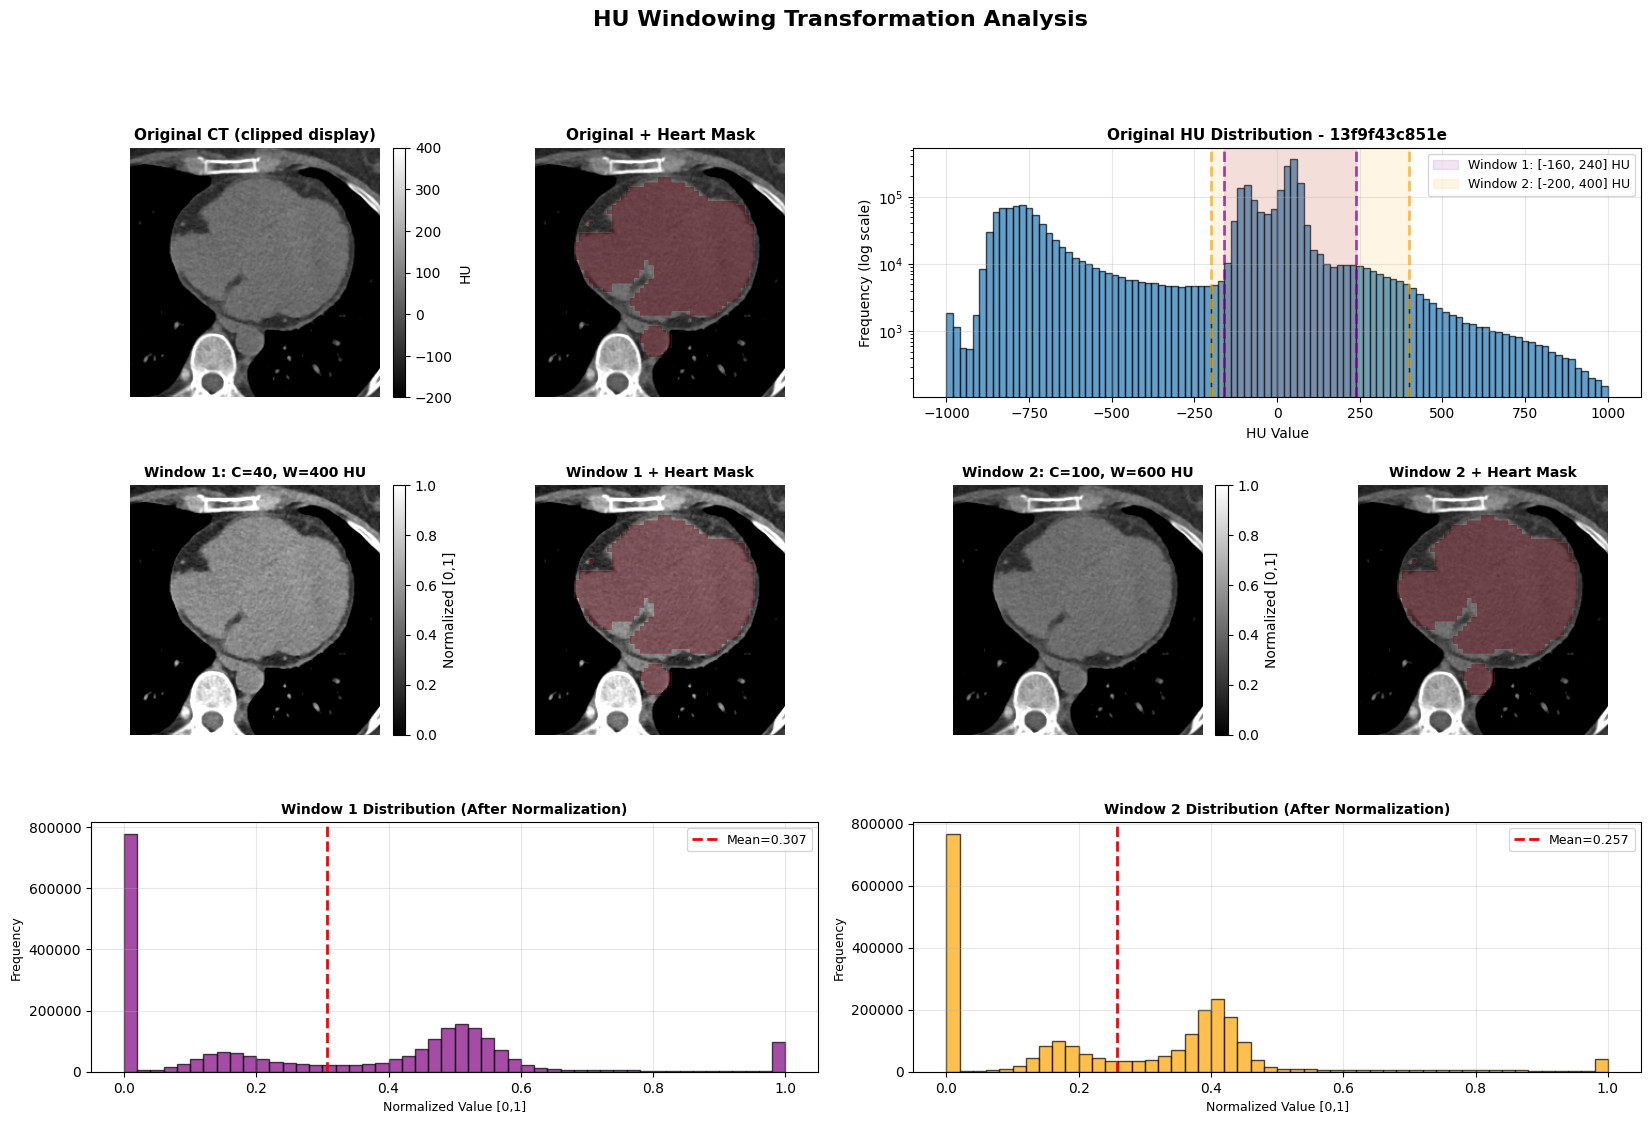


HU WINDOWING TRANSFORMATION SUMMARY
Scan: 13f9f43c851e
Original HU range: [-1023.0, 1203.0]
Original HU mean: -200.0 ± 365.8

Multi-window configuration (2 channels):
  Window 1: Center=40 HU, Width=400 HU → Range=[-160, 240] HU
           Normalized mean: 0.307 ± 0.275
  Window 2: Center=100 HU, Width=600 HU → Range=[-200, 400] HU
           Normalized mean: 0.257 ± 0.225

Heart segmentation: 385551 / 2518776 voxels (15.31%)

✓ Windowing analysis saved to: C:\CT_Datasets\preprocessed_data\windowing_analysis.png


In [16]:
 # Visualize HU Windowing Effect on Dataset
print("Creating detailed HU windowing visualization...")

# Select a representative scan from training set
viz_scan = train_scans[2] if len(train_scans) > 2 else train_scans[0]
viz_img_path = config.DATA_DIR / viz_scan / f"{viz_scan}_img.nii.gz"
viz_seg_path = config.DATA_DIR / viz_scan / f"{viz_scan}_seg.nii.gz"

# Load original CT data
viz_img_sitk = sitk.ReadImage(str(viz_img_path))
viz_seg_sitk = sitk.ReadImage(str(viz_seg_path))
viz_img_original = sitk.GetArrayFromImage(viz_img_sitk).astype(np.float32)
viz_seg = sitk.GetArrayFromImage(viz_seg_sitk)

# Apply windowing transformations
if config.USE_MULTI_WINDOW:
    viz_img_windowed = apply_multi_windowing(viz_img_original, config.WINDOW_PAIRS)
    n_windows = len(config.WINDOW_PAIRS)
else:
    viz_img_windowed = apply_hu_windowing(
        viz_img_original, 
        config.PRIMARY_WINDOW_CENTER, 
        config.PRIMARY_WINDOW_WIDTH
    )
    n_windows = 1

# Create comprehensive visualization
if config.USE_MULTI_WINDOW:
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)
else:
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3)

mid_slice = viz_img_original.shape[0] // 2

# Row 1: Original HU visualization
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(viz_img_original[mid_slice], cmap='gray', vmin=-200, vmax=400)
ax1.set_title('Original CT (clipped display)', fontsize=11, weight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='HU')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(viz_img_original[mid_slice], cmap='gray', vmin=-200, vmax=400)
ax2.imshow(viz_seg[mid_slice], cmap='Reds', alpha=0.4 * (viz_seg[mid_slice] > 0))
ax2.set_title('Original + Heart Mask', fontsize=11, weight='bold')
ax2.axis('off')

# HU histogram with window ranges
ax3 = fig.add_subplot(gs[0, 2:])
hu_values = viz_img_original.flatten()
ax3.hist(hu_values, bins=100, alpha=0.7, color='#1f77b4', edgecolor='black', range=(-1000, 1000))
ax3.set_xlabel('HU Value', fontsize=10)
ax3.set_ylabel('Frequency (log scale)', fontsize=10)
ax3.set_yscale('log')
ax3.set_title(f'Original HU Distribution - {viz_scan}', fontsize=11, weight='bold')

# Mark window ranges
if config.USE_MULTI_WINDOW:
    colors_win = ['purple', 'orange']
    for idx, item in enumerate(config.WINDOW_PAIRS):
        if isinstance(item, dict):
            center, width = item["center"], item["width"]
        else:
            center, width = item
        min_hu = center - width // 2
        max_hu = center + width // 2
        ax3.axvline(min_hu, color=colors_win[idx], linestyle='--', alpha=0.7, linewidth=2)
        ax3.axvline(max_hu, color=colors_win[idx], linestyle='--', alpha=0.7, linewidth=2)
        ax3.axvspan(min_hu, max_hu, alpha=0.1, color=colors_win[idx], 
                    label=f'Window {idx+1}: [{min_hu}, {max_hu}] HU')
else:
    ax3.axvline(config.HU_MIN, color='purple', linestyle='--', alpha=0.7, linewidth=2)
    ax3.axvline(config.HU_MAX, color='purple', linestyle='--', alpha=0.7, linewidth=2)
    ax3.axvspan(config.HU_MIN, config.HU_MAX, alpha=0.15, color='purple',
                label=f'Window: [{config.HU_MIN}, {config.HU_MAX}] HU')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# Row 2+: Windowed results
if config.USE_MULTI_WINDOW:
    for idx in range(n_windows):
        if isinstance(config.WINDOW_PAIRS[idx], dict):
            center = config.WINDOW_PAIRS[idx]["center"]
            width = config.WINDOW_PAIRS[idx]["width"]
        else:
            center, width = config.WINDOW_PAIRS[idx]
        
        # Windowed image
        ax_img = fig.add_subplot(gs[1, idx*2])
        im = ax_img.imshow(viz_img_windowed[idx, mid_slice], cmap='gray', vmin=0, vmax=1)
        ax_img.set_title(f'Window {idx+1}: C={center}, W={width} HU', fontsize=10, weight='bold')
        ax_img.axis('off')
        plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04, label='Normalized [0,1]')
        
        # Windowed + mask
        ax_mask = fig.add_subplot(gs[1, idx*2+1])
        ax_mask.imshow(viz_img_windowed[idx, mid_slice], cmap='gray', vmin=0, vmax=1)
        ax_mask.imshow(viz_seg[mid_slice], cmap='Reds', alpha=0.4 * (viz_seg[mid_slice] > 0))
        ax_mask.set_title(f'Window {idx+1} + Heart Mask', fontsize=10, weight='bold')
        ax_mask.axis('off')
        
        # Histogram
        ax_hist = fig.add_subplot(gs[2, idx*2:(idx+1)*2])
        windowed_values = viz_img_windowed[idx].flatten()
        ax_hist.hist(windowed_values, bins=50, alpha=0.7, color=colors_win[idx], edgecolor='black')
        ax_hist.set_xlabel('Normalized Value [0,1]', fontsize=9)
        ax_hist.set_ylabel('Frequency', fontsize=9)
        ax_hist.set_title(f'Window {idx+1} Distribution (After Normalization)', fontsize=10, weight='bold')
        ax_hist.axvline(windowed_values.mean(), color='red', linestyle='--', 
                       label=f'Mean={windowed_values.mean():.3f}', linewidth=2)
        ax_hist.legend(fontsize=9)
        ax_hist.grid(alpha=0.3)
else:
    # Single window visualization
    ax4 = fig.add_subplot(gs[1, 0])
    im4 = ax4.imshow(viz_img_windowed[mid_slice], cmap='gray', vmin=0, vmax=1)
    ax4.set_title(f'Windowed: C={config.PRIMARY_WINDOW_CENTER}, W={config.PRIMARY_WINDOW_WIDTH} HU', 
                  fontsize=11, weight='bold')
    ax4.axis('off')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04, label='Normalized [0,1]')
    
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.imshow(viz_img_windowed[mid_slice], cmap='gray', vmin=0, vmax=1)
    ax5.imshow(viz_seg[mid_slice], cmap='Reds', alpha=0.4 * (viz_seg[mid_slice] > 0))
    ax5.set_title('Windowed + Heart Mask', fontsize=11, weight='bold')
    ax5.axis('off')
    
    # Windowed histogram
    ax6 = fig.add_subplot(gs[1, 2:])
    windowed_values = viz_img_windowed.flatten()
    ax6.hist(windowed_values, bins=50, alpha=0.7, color='#ab68c8', edgecolor='black')
    ax6.set_xlabel('Normalized Value [0,1]', fontsize=10)
    ax6.set_ylabel('Frequency', fontsize=10)
    ax6.set_title('Windowed Distribution (After Normalization)', fontsize=11, weight='bold')
    ax6.axvline(windowed_values.mean(), color='red', linestyle='--', 
               label=f'Mean={windowed_values.mean():.3f}', linewidth=2)
    ax6.legend(fontsize=10)
    ax6.grid(alpha=0.3)

plt.suptitle('HU Windowing Transformation Analysis', fontsize=16, weight='bold', y=0.995)
plt.savefig(config.OUTPUT_DIR / 'windowing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print transformation summary
print("\n" + "="*80)
print("HU WINDOWING TRANSFORMATION SUMMARY")
print("="*80)
print(f"Scan: {viz_scan}")
print(f"Original HU range: [{viz_img_original.min():.1f}, {viz_img_original.max():.1f}]")
print(f"Original HU mean: {viz_img_original.mean():.1f} ± {viz_img_original.std():.1f}")

if config.USE_MULTI_WINDOW:
    print(f"\nMulti-window configuration ({n_windows} channels):")
    for idx, item in enumerate(config.WINDOW_PAIRS):
        if isinstance(item, dict):
            center, width = item["center"], item["width"]
        else:
            center, width = item
        min_hu = center - width // 2
        max_hu = center + width // 2
        win_mean = viz_img_windowed[idx].mean()
        win_std = viz_img_windowed[idx].std()
        print(f"  Window {idx+1}: Center={center} HU, Width={width} HU → Range=[{min_hu}, {max_hu}] HU")
        print(f"           Normalized mean: {win_mean:.3f} ± {win_std:.3f}")
else:
    print(f"\nSingle-window configuration:")
    print(f"  Center={config.PRIMARY_WINDOW_CENTER} HU, Width={config.PRIMARY_WINDOW_WIDTH} HU")
    print(f"  Range: [{config.HU_MIN}, {config.HU_MAX}] HU")
    print(f"  Normalized mean: {viz_img_windowed.mean():.3f} ± {viz_img_windowed.std():.3f}")

print(f"\nHeart segmentation: {(viz_seg > 0).sum()} / {viz_seg.size} voxels ({(viz_seg > 0).sum()/viz_seg.size*100:.2f}%)")
print("="*80)
print(f"\n✓ Windowing analysis saved to: {config.OUTPUT_DIR / 'windowing_analysis.png'}")


In [17]:
# Export statistics to JSON (includes both original HU stats and windowed/normalized stats)
statistics_summary = {
    'dataset': 'COCA Cardiac CT',
    'preprocessing': {
        'hu_windowing': {
            'center': config.PRIMARY_WINDOW_CENTER,
            'width': config.PRIMARY_WINDOW_WIDTH,
            'range': [config.HU_MIN, config.HU_MAX],
            'multi_window': config.USE_MULTI_WINDOW,
            'window_pairs': config.WINDOW_PAIRS
        },
        'augmentation': {
            'spatial': ['rand_affine', 'rand_3d_elastic'],
            'spatial_params': {
                'affine_prob': 0.5,
                'rotate_range_rad': [0.0873, 0.0873, 0.1745],
                'translate_range_voxels': [5, 5, 2],
                'scale_range': [0.1, 0.1, 0.05],
                'elastic_prob': 0.3,
                'elastic_sigma_range': [5, 7],
                'elastic_magnitude_range': [1, 2]
            },
            'intensity': ['gaussian_noise', 'gaussian_smooth', 'intensity_scale', 'intensity_shift'],
            'intensity_params': {
                'noise_prob': 0.2,
                'smooth_prob': 0.2,
                'scale_prob': 0.3,
                'shift_prob': 0.3
            }
        },
        'target_spacing_mm': list(config.TARGET_SPACING)
    },
    'splits': {
        'train': {
            'n_scans': len(train_scans),
            'percentage': f"{len(train_scans)/len(all_valid_scans)*100:.1f}"
        },
        'val': {
            'n_scans': len(val_scans),
            'percentage': f"{len(val_scans)/len(all_valid_scans)*100:.1f}"
        },
        'test': {
            'n_scans': len(test_scans),
            'percentage': f"{len(test_scans)/len(all_valid_scans)*100:.1f}"
        }
    },
    'statistics': {}
}

# Add detailed statistics
for stats, name, w_means in zip(all_stats, split_names, windowed_stats):
    seg_ratios = np.array(stats['seg_ratios']) * 100
    volumes = np.array(stats['volumes'])
    
    statistics_summary['statistics'][name.lower()] = {
        'n_scans': stats['n_scans'],
        'avg_heart_volume_percent': float(np.mean(seg_ratios)),
        'std_heart_volume_percent': float(np.std(seg_ratios)),
        'avg_total_voxels': float(np.mean(volumes)),
        'avg_hu_mean': float(np.mean([s['mean'] for s in stats['hu_stats']])),
        'avg_hu_std': float(np.mean([s['std'] for s in stats['hu_stats']])),
        'max_hu_std': float(np.max([s['std'] for s in stats['hu_stats']])),
        'min_hu_std': float(np.min([s['std'] for s in stats['hu_stats']])),
        'avg_windowed_mean': float(np.mean(w_means)),
        'std_windowed_mean': float(np.std(w_means)),
        'windowed_note': 'After HU windowing and [0,1] normalization (actual model input)'
    }

# Save to JSON
with open(config.OUTPUT_DIR / 'dataset_statistics.json', 'w') as f:
    json.dump(statistics_summary, f, indent=2)

print("\n" + "="*80)
print("DATASET STATISTICS SUMMARY")
print("="*80)
print(json.dumps(statistics_summary, indent=2))
print("="*80)
print(f"\nStatistics saved to: {config.OUTPUT_DIR / 'dataset_statistics.json'}")


DATASET STATISTICS SUMMARY
{
  "dataset": "COCA Cardiac CT",
  "preprocessing": {
    "hu_windowing": {
      "center": 100,
      "width": 600,
      "range": [
        -200,
        400
      ],
      "multi_window": true,
      "window_pairs": [
        {
          "center": 40,
          "width": 400
        },
        {
          "center": 100,
          "width": 600
        }
      ]
    },
    "augmentation": {
      "spatial": [
        "rand_affine",
        "rand_3d_elastic"
      ],
      "spatial_params": {
        "affine_prob": 0.5,
        "rotate_range_rad": [
          0.0873,
          0.0873,
          0.1745
        ],
        "translate_range_voxels": [
          5,
          5,
          2
        ],
        "scale_range": [
          0.1,
          0.1,
          0.05
        ],
        "elastic_prob": 0.3,
        "elastic_sigma_range": [
          5,
          7
        ],
        "elastic_magnitude_range": [
          1,
          2
        ]
      },
      "

## 8. Preprocessing Pipeline Justification

### Design Decisions and Rationale

**HU Windowing for Cardiac CT:**
The pipeline applies cardiac-optimized HU windowing with center=100 HU and width=600 HU (range [-200, 400] HU) to capture myocardium (~50 HU), blood pools (40-50 HU), vessels, and calcifications (>130 HU), then normalizes to [0,1] for model convergence. Multi-window support allows stacking complementary tissue contrasts as channels—for example, combining a soft tissue window (center=40, width=400) with a broader cardiac window (center=100, width=600) provides richer anatomical information by emphasizing different tissue types.

**Data Augmentation:**
The augmentation strategy employs 3D transforms to improve generalization while preserving anatomical realism. Spatial transforms include RandAffine (prob=0.5: ±5° in-plane, ±10° through-plane rotations; 5,5,2 voxel translations; ±10%/5% scaling) and Rand3DElastic (prob=0.3: sigma 5-7, magnitude 1-2) for anatomical variability. Intensity transforms include Gaussian noise (prob=0.2, std=0.01), Gaussian smoothing (prob=0.2, sigma 0.5-1.0), and intensity scaling/shifting (prob=0.3) to simulate scanner variations. All spatial transforms are applied jointly to image and mask to maintain alignment.

**Stratified Split:**
The dataset uses stratified splitting based on heart segmentation volume (tertiles) to ensure balanced representation across train/val/test splits (70%/15%/15%). Segmentation ratios are computed for each scan, divided into tertiles, then allocated using scikit-learn's stratified splitting to maintain similar heart size distributions in each subset. Fixed random seed (42) ensures reproducibility.

**Data Loader:**
The custom PyTorch Dataset provides memory-efficient on-the-fly loading with variable-sized 3D volume support. HU windowing is applied dynamically during batch generation rather than pre-computed, reducing storage requirements. Training uses a custom `StratifiedBatchSampler` that groups scans by heart-size tertile and round-robins across groups when filling each batch, ensuring every batch contains a mix of small, medium, and large heart scans with no replacement — every scan is seen exactly once per epoch. The real class imbalance is at the voxel level (heart ≈ 3–5 % of all voxels), which is handled by a computed `pos_weight` parameter for `BCEWithLogitsLoss` (ratio of background to heart voxels, ≈ 20–30×).

**Statistics Visualization:**
The statistics visualization reports post-preprocessing windowed/normalized [0,1] values rather than original HU values, ensuring transparency about actual model input distributions. This is critical because windowing and normalization fundamentally alter intensity distributions. multi-window transformation analysis with before/after comparisons, and tables explicitly labeled "Mean [0,1]" and "Std [0,1]" to distinguish preprocessed values from original HU measurements.

## 9. Summary and Next Steps

### Deliverables Completed ✓

1. **Pipeline Code**: Complete preprocessing pipeline with modular functions
2. **Data Loader**: Efficient PyTorch Dataset and DataLoader for cardiac CT
3. **Written Justification**: Detailed rationale for all preprocessing choices (see Section 8)
4. **Dataset Statistics**: Comprehensive statistical analysis with visualizations 
5. **Windowing Analysis**: Detailed multi-window transformation visualization with before/after comparisons

### Outputs Generated

- `preprocessed_data/data_split.json` - Train/val/test split assignments
- `preprocessed_data/dataset_statistics.json` - Comprehensive statistics with windowing parameters
- `preprocessed_data/comprehensive_statistics.png` - Statistical overview visualization 
- `preprocessed_data/hu_windowing_effect.png` - Initial HU windowing demonstration
- `preprocessed_data/windowing_analysis.png` - Detailed multi-window transformation analysis
- `preprocessed_data/sample_visualization.png` - Sample data visualization from DataLoader
- `preprocessed_data/augmentation_preview.png` - Before/after augmentation visualization

### Next Steps for Project 1


1. **Train U-Net Model**: Use this data loader with lightweight U-Net architecture
2. **Evaluate Performance**: Compare Dice scores and inference times against TotalSegmentator

### Key Features of This Pipeline

- ✅ Cardiac-optimized HU windowing (multi-window support)
- ✅ Comprehensive 3D data augmentation  
- ✅ Stratified dataset splitting
- ✅ Memory-efficient data loading
- ✅ Handles variable-sized volumes
- ✅ Segmentation-optimized preprocessing
- ✅ Reproducible (fixed random seeds)
- ✅ Well-documented and modular code
- ✅ Detailed windowing transformation analysis
- ✅ Statistics showing both raw HU and normalized distributions